<div align="center">

<h1> <b> DECAIMIENTO RADIACTIVO: ESTIMACIÓN DE LA VIDA MEDIA Y COMPARACIÓN DE SIMULACIONES </b> </h1>

</div>

<br>

<hr size=10 noshade color="green">
<p>
<p><img alt="UdeA logo" height="180px" src="https://upload.wikimedia.org/wikipedia/commons/archive/f/fb/20161010213812%21Escudo-UdeA.svg" align="left" hspace="100px" vspace="4px"></p>

<div align="right">       

<h3><i> <b>Rosa Mercedes Salazar Miranda <br>
Cristian Camilo Vergara Restrepo <br>
Sebastián Eladio Mena Torres</b> <br>  
Universidad de Antioquia <br>
Instituto de Física  <br>
</i></h3>
</div>

---


## Introducción

El decaimiento radiactivo es uno de los fenómenos fundamentales de la física nuclear. Se caracteriza por ser un proceso espontáneo mediante el cual núcleos atómicos inestables pierden energía emitiendo radiación en forma de partículas o de ondas electromagnéticas, transformándose progresivamente en estados más estables. A nivel macroscópico, este comportamiento se modela de manera determinista mediante una ley de decaimiento exponencial decreciente, gobernada por una constante de desintegración específica ($\lambda$) y caracterizada por el concepto de vida media ($T_{1/2}$), que representa el tiempo requerido para que la mitad de una población inicial de núcleos se desintegre.

No obstante, a nivel microscópico, la desintegración de un núcleo individual es un evento puramente estocástico y probabilístico. Es imposible predecir con certeza en qué instante preciso se desintegrará un núcleo en particular; solo podemos determinar la probabilidad de que esto ocurra en un intervalo de tiempo dado. Esta dualidad entre el determinismo estadístico de los grandes números y la naturaleza inherentemente aleatoria del proceso a pequeña escala es de vital importancia para la comprensión de los sistemas físicos cuánticos.

En este trabajo se presenta un estudio computacional dividido en dos partes. En la **Parte A**, analizamos los datos de dos simulaciones de decaimiento que parten de $N_0 = 400$ núcleos: uno de vida media intermedia y otro de vida media prolongada. Implementamos y contrastamos dos metodologías de ajuste para estimar el tiempo de vida media: un ajuste exponencial directo no lineal mediante mínimos cuadrados, y un ajuste lineal tras la linealización logarítmica de los datos. En la **Parte B**, evaluamos de forma empírica la naturaleza estadística del fenómeno, deteniendo repetidamente nuevas simulaciones en el instante exacto de la vida media calculada para cuantificar la dispersión y las fluctuaciones del número de núcleos sobrevivientes alrededor del valor esperado de la mitad de la población original.

### Objetivo general

Estimar el tiempo de vida media de dos procesos simulados de decaimiento radiactivo, uno de vida media intermedia y otro de vida media más prolongada, a partir de ajustes exponencial y lineal (Bevington & Robinson, 2003) sobre el número de núcleos no desintegrados en función del tiempo, y contrastar estas estimaciones con los resultados obtenidos al repetir la simulación deteniéndola en el instante correspondiente a la vida media calculada.

### Datos de la simulación

La simulación registra, cada 4 segundos entre $t=0$ s y $t=100$ s, el número de núcleos no desintegrados $N$ para dos procesos de decaimiento que parten de $N_0 = 400$ núcleos: uno de vida media intermedia (**N_medium**) y otro de vida media más prolongada (**N_large**).

# PARTE A (Toma de datos y cálculo del tiempo de vida media)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

**Pregunta 1.** Elabore un diagrama en el que $N$ represente el número de núcleos no desintegrados en el eje $y$, y $t$ represente el tiempo en el eje $x$. Los puntos de datos exhibirán una dispersión considerable; sin embargo, es posible trazar una curva suave, similar a una curva de decaimiento exponencial, que represente el "mejor ajuste" a los datos.


In [2]:
"""
Datos de la simulación de decaimiento radiactivo (Parte A).

Se registran, cada 4 segundos, el número de núcleos no desintegrados para
los dos procesos simulados (N_medium y N_large), ambos con N0 = 400.
"""
t_data = np.array([0, 4, 8, 12, 16, 20, 24, 28, 32, 36, 40, 44, 48, 52, 56,
                    60, 64, 68, 72, 76, 80, 84, 88, 92, 96, 100], dtype=float)

N_medium_data = np.array([400, 343, 285, 251, 221, 186, 161, 139, 116, 108,
                           91, 74, 60, 51, 47, 42, 35, 30, 28, 27, 23, 19,
                           17, 14, 14, 13], dtype=float)

N_large_data = np.array([400, 371, 344, 314, 295, 272, 251, 236, 221, 211,
                          195, 176, 167, 153, 144, 125, 117, 105, 95, 88,
                          76, 70, 65, 60, 55, 50], dtype=float)

data = pd.DataFrame({
    'Tiempo': t_data,
    'N_medium': N_medium_data,
    'N_large': N_large_data,
})
data.head()


,Tiempo,N_medium,N_large
0,0.0,400.0,400.0
1,4.0,343.0,371.0
2,8.0,285.0,344.0
3,12.0,251.0,314.0
4,16.0,221.0,295.0


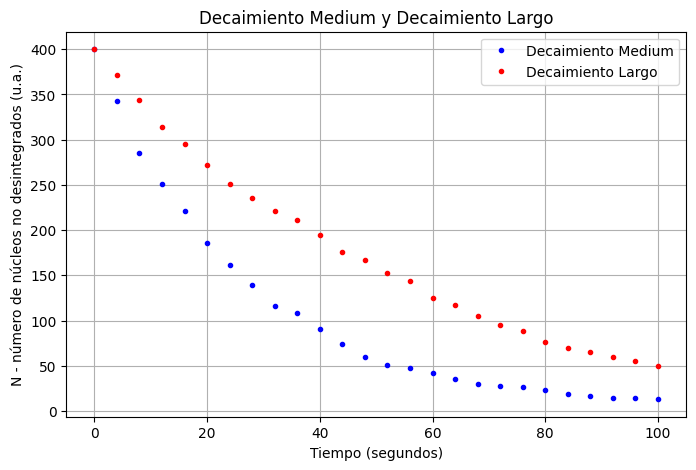

In [3]:
# Diagrama N vs. t para los dos procesos de decaimiento
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(data['Tiempo'], data['N_medium'], '.', label='Decaimiento Medium', color='b')
ax.plot(data['Tiempo'], data['N_large'], '.', label='Decaimiento Largo', color='r')

ax.set_xlabel('Tiempo (segundos)')
ax.set_ylabel('N - número de núcleos no desintegrados (u.a.)')
ax.set_title('Decaimiento Medium y Decaimiento Largo')
ax.legend()
ax.grid()
plt.show()


La gráfica muestra la simulación del decaimiento radiactivo de una partícula arbitraria a lo largo del tiempo, para dos procesos de desintegración distintos:

- **Medium** (azul): decaimiento con una vida media intermedia.
- **Largo** (rojo): decaimiento con una vida media más prolongada.

En ambos casos, la cantidad de núcleos no desintegrados disminuye de forma exponencial, siguiendo la ley de decaimiento radiactivo.


**Pregunta 2.** Utilice un ajuste de curva o de recta para calcular la vida media de cada núcleo, empleando los datos obtenidos en la simulación.


### Ajuste exponencial

Antes de realizar el ajuste, se estimó a partir de la simulación un valor aproximado del tiempo de vida media para cada proceso:

- $T_{1/2}^{\,medium} \approx 19$ s
- $T_{1/2}^{\,large} \approx 34$ s

Utilizando la relación $T_{1/2} = \ln(2)/\lambda$ (Krane, 1988), estos valores permiten obtener una estimación inicial de la constante de desintegración $\lambda$:

- $\lambda^{\,medium} \approx 0{,}037\ \text{s}^{-1}$
- $\lambda^{\,large} \approx 0{,}021\ \text{s}^{-1}$

Estos valores se emplean como punto de partida (`p0`) del ajuste no lineal realizado con `curve_fit`.

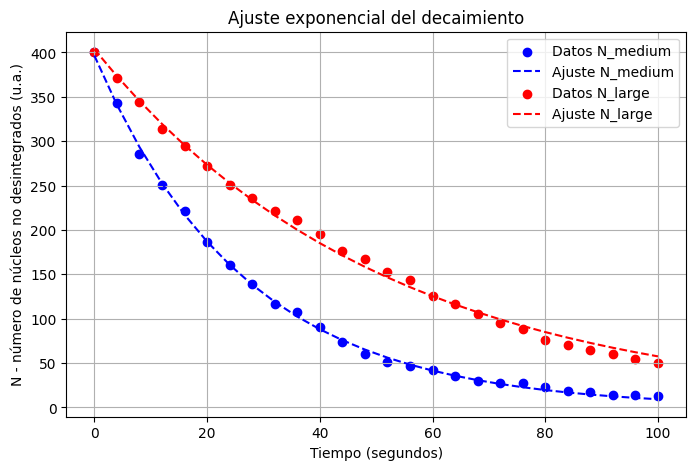

In [4]:
def decay_function(t, N0, lamb):
    """
    Modelo de decaimiento exponencial N(t) = N0 * exp(-lambda * t).

    Parameters
    ----------
    t : array_like
        Tiempo transcurrido, en segundos.
    N0 : float
        Número inicial de núcleos.
    lamb : float
        Constante de desintegración, en s^-1.

    Returns
    -------
    numpy.ndarray
        Número de núcleos no desintegrados en cada instante t.
    """
    return N0 * np.exp(-lamb * t)


# Ajuste exponencial para cada proceso de decaimiento; los valores iniciales
# de lambda provienen de la estimación hecha a partir de la simulación.
params_medium_exp, _ = curve_fit(decay_function, t_data, N_medium_data, p0=[400, 0.037])
N0_medium_exp, lambda_medium_exp = params_medium_exp

params_large_exp, _ = curve_fit(decay_function, t_data, N_large_data, p0=[400, 0.021])
N0_large_exp, lambda_large_exp = params_large_exp

# Vida media a partir de la constante de desintegración ajustada
tau_medium_exp = np.log(2) / lambda_medium_exp
tau_large_exp = np.log(2) / lambda_large_exp

t_fit = np.linspace(t_data.min(), t_data.max(), len(t_data))

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(t_data, N_medium_data, color='b', label='Datos N_medium')
ax.plot(t_fit, decay_function(t_fit, *params_medium_exp), 'b--', label='Ajuste N_medium')

ax.scatter(t_data, N_large_data, color='r', label='Datos N_large')
ax.plot(t_fit, decay_function(t_fit, *params_large_exp), 'r--', label='Ajuste N_large')

ax.set_xlabel('Tiempo (segundos)')
ax.set_ylabel('N - número de núcleos no desintegrados (u.a.)')
ax.set_title('Ajuste exponencial del decaimiento')
ax.legend()
ax.grid()
plt.show()


La gráfica muestra el ajuste exponencial de la desintegración radiactiva simulada para los dos procesos:

- **N_medium** (azul): núcleo con vida media intermedia.
- **N_large** (rojo): núcleo con vida media más prolongada.

Los puntos corresponden a los datos simulados, y las líneas punteadas representan el ajuste obtenido mediante $N(t) = N_0\, e^{-\lambda t}$, donde $N_0$ es el número inicial de núcleos y $\lambda$ es la constante de desintegración. A partir del valor ajustado de $\lambda$ se calcula la vida media $T_{1/2} = \ln(2)/\lambda$.


### Ajuste lineal (logarítmico)

Dado que el decaimiento radiactivo es exponencial, un ajuste lineal sobre los datos originales no representa bien su tendencia. Sin embargo, al tomar el logaritmo natural de los datos, la ecuación de decaimiento se linealiza:

$$
\ln(N) = \ln(N_0) - \lambda t
$$


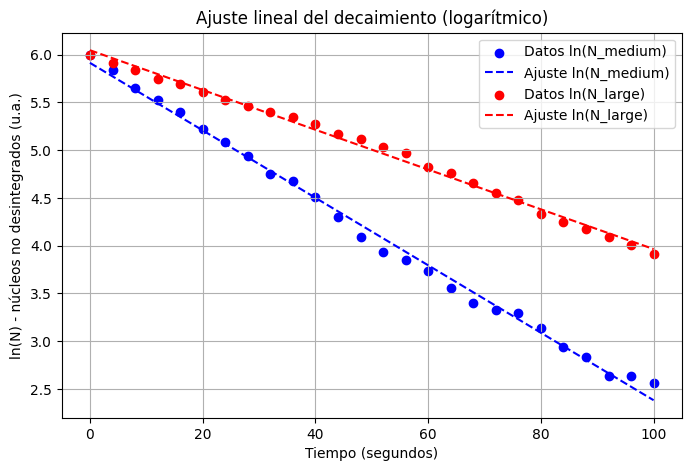

In [5]:
def log_decay(t, ln_N0, lamb):
    """
    Modelo lineal del logaritmo del decaimiento exponencial:
    ln(N) = ln(N0) - lambda * t.

    Parameters
    ----------
    t : array_like
        Tiempo transcurrido, en segundos.
    ln_N0 : float
        Logaritmo natural del número inicial de núcleos.
    lamb : float
        Constante de desintegración, en s^-1.

    Returns
    -------
    numpy.ndarray
        Logaritmo natural del número de núcleos no desintegrados en cada
        instante t.
    """
    return ln_N0 - lamb * t


# Se aplica el logaritmo natural a los datos y se ajusta la recta resultante
ln_N_medium = np.log(N_medium_data)
ln_N_large = np.log(N_large_data)

params_medium_lin, _ = curve_fit(log_decay, t_data, ln_N_medium)
params_large_lin, _ = curve_fit(log_decay, t_data, ln_N_large)

ln_N0_medium_lin, lambda_medium_lin = params_medium_lin
ln_N0_large_lin, lambda_large_lin = params_large_lin

# Se recupera N0 a partir de su logaritmo, y se calcula la vida media
N0_medium_lin = np.exp(ln_N0_medium_lin)
N0_large_lin = np.exp(ln_N0_large_lin)

tau_medium_lin = np.log(2) / lambda_medium_lin
tau_large_lin = np.log(2) / lambda_large_lin

t_fit = np.linspace(t_data.min(), t_data.max(), len(t_data))
ln_fit_medium = log_decay(t_fit, ln_N0_medium_lin, lambda_medium_lin)
ln_fit_large = log_decay(t_fit, ln_N0_large_lin, lambda_large_lin)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(t_data, ln_N_medium, color='b', label='Datos ln(N_medium)')
ax.plot(t_fit, ln_fit_medium, 'b--', label='Ajuste ln(N_medium)')

ax.scatter(t_data, ln_N_large, color='r', label='Datos ln(N_large)')
ax.plot(t_fit, ln_fit_large, 'r--', label='Ajuste ln(N_large)')

ax.set_xlabel('Tiempo (segundos)')
ax.set_ylabel('ln(N) - núcleos no desintegrados (u.a.)')
ax.set_title('Ajuste lineal del decaimiento (logarítmico)')
ax.legend()
ax.grid()
plt.show()

Al graficar $\ln(N)$ en función de $t$ se obtiene una recta, consistente con el modelo linealizado $\ln(N) = \ln(N_0) - \lambda t$, donde $\ln(N_0)$ es el logaritmo del número inicial de núcleos y $\lambda$ es la constante de desintegración. Los puntos corresponden a los datos simulados y las líneas punteadas representan el ajuste lineal para cada proceso:

- Medium (azul): decaimiento con una vida media intermedia.
- Largo (rojo): decaimiento con una vida media más prolongada.


### Resultados de los ajustes exponencial y lineal

In [6]:
resumen_ajustes = pd.DataFrame({
    'Proceso': ['N_medium', 'N_large', 'N_medium', 'N_large'],
    'Ajuste': ['Exponencial', 'Exponencial', 'Lineal (log)', 'Lineal (log)'],
    'N0': [N0_medium_exp, N0_large_exp, N0_medium_lin, N0_large_lin],
    'lambda (1/s)': [lambda_medium_exp, lambda_large_exp, lambda_medium_lin, lambda_large_lin],
    'Vida media T_1/2 (s)': [tau_medium_exp, tau_large_exp, tau_medium_lin, tau_large_lin],
}).round({'N0': 2, 'lambda (1/s)': 4, 'Vida media T_1/2 (s)': 2})

resumen_ajustes


,Proceso,Ajuste,N0,lambda (1/s),Vida media T_1/2 (s)
0,N_medium,Exponencial,396.47,0.0376,18.43
1,N_large,Exponencial,403.61,0.0195,35.57
2,N_medium,Lineal (log),369.89,0.0353,19.64
3,N_large,Lineal (log),422.22,0.0208,33.31


### Conclusión (Parte A)

Ambos ajustes, exponencial y lineal (logarítmico), proporcionan estimaciones similares de la vida media para los dos procesos simulados, lo que confirma que la desintegración radiactiva sigue un comportamiento exponencial. La ligera variación entre los valores obtenidos por cada método (18.43 s frente a 19.64 s para N_medium, y 35.57 s frente a 33.31 s para N_large) es atribuible a la naturaleza estadística del proceso de desintegración y a las fluctuaciones propias de los datos simulados.

Esta diferencia se encuentra dentro del margen de error de ±3 segundos considerado en el curso, lo que indica que ambos métodos son coherentes dentro de los límites de incertidumbre establecidos. Para las comparaciones de la Parte B se toman como valores de referencia 18 s (N_medium) y 35 s (N_large), cercanos a las estimaciones obtenidas en ambos ajustes.

# PARTE B (Análisis y comparación del tiempo de vida media con la simulación)

**Pregunta 3.** Reinicie la simulación con un valor inicial de $N = 400$, deteniendo cada ejecución en el instante más cercano al valor calculado de la vida media, y registre el valor de $N$ en ese instante.


In [7]:
"""
Datos de la Parte B: número de núcleos no desintegrados al detener la
simulación en el instante correspondiente a la vida media estimada en la
Parte A (18 s para N_medium y 35 s para N_large), repitiendo el
experimento 10 veces para cada proceso.
"""
N_medium_T12 = [200, 204, 198, 183, 194, 199, 198, 204, 202, 181]
N_large_T12 = [198, 181, 201, 209, 213, 197, 211, 206, 199, 203]

data1 = pd.DataFrame({
    'N_medium (T_1/2 = 18s)': N_medium_T12,
    'N_large (T_1/2 = 35s)': N_large_T12,
})
data1


,N_medium (T_1/2 = 18s),N_large (T_1/2 = 35s)
0,200,198
1,204,181
2,198,201
3,183,209
4,194,213
5,199,197
6,198,211
7,204,206
8,202,199
9,181,203


Esta tabla muestra los valores de $N$ obtenidos al detener la simulación en el instante correspondiente a la vida media estimada en la Parte A: 18 segundos para el proceso de vida media intermedia y 35 segundos para el de vida media más prolongada. El experimento se repitió 10 veces para cada uno de los dos procesos de decaimiento.


**Pregunta 4.** Si cada ejecución fuera perfectamente reproducible, aproximadamente 200 núcleos permanecerían inalterados tras una vida media. De acuerdo con los datos obtenidos, ¿ha habido ocasiones en las que el valor de $N$ excede 200 tras una vida media? De ser así, ¿cuántas veces ocurre esto en las diez ejecuciones documentadas? ¿Cuál es su interpretación respecto a la naturaleza de la desintegración radiactiva?


In [8]:
# Número de ejecuciones en las que N supera 200 núcleos tras una vida media
count_medium = (data1['N_medium (T_1/2 = 18s)'] > 200).sum()
count_large = (data1['N_large (T_1/2 = 35s)'] > 200).sum()

print(f"Cantidad de núcleos no desintegrados al cabo de N_medium (T_1/2 = 18s) "
      f"mayores a 200 es: {count_medium} de 10 veces, lo que equivale al "
      f"{100 * count_medium / 10:.1f} % de las observaciones.")
print(f"Cantidad de núcleos no desintegrados al cabo de N_large (T_1/2 = 35s) "
      f"mayores a 200 es: {count_large} de 10 veces, lo que equivale al "
      f"{100 * count_large / 10:.1f} % de las observaciones.")


Cantidad de núcleos no desintegrados al cabo de N_medium (T_1/2 = 18s) mayores a 200 es: 3 de 10 veces, lo que equivale al 30.0 % de las observaciones.
Cantidad de núcleos no desintegrados al cabo de N_large (T_1/2 = 35s) mayores a 200 es: 6 de 10 veces, lo que equivale al 60.0 % de las observaciones.


### Interpretación de los resultados

El decaimiento radiactivo es un proceso probabilístico: no todos los núcleos decaen exactamente a la misma velocidad, por lo que en algunas ejecuciones sobreviven más o menos núcleos de los esperados por simple azar.

Estas fluctuaciones son normales considerando que la muestra analizada es finita: aunque la vida media es un valor esperado, cada decaimiento individual es un proceso aleatorio, y con solo 400 núcleos es razonable observar variaciones entre ejecuciones.

De la teoría se sabe que, a mayor número de núcleos, menor es la variabilidad relativa; por ello cabe esperar que, si el experimento se realizara con millones de núcleos, las fluctuaciones se reducirían y el valor de $N(\tau)$ se ajustaría más consistentemente al esperado en cada ejecución.


### Referencias

- Krane, K. S. (1988). *Introductory nuclear physics*. John Wiley & Sons.
- Bevington, P. R., & Robinson, D. K. (2003). *Data reduction and error analysis for the physical sciences* (3rd ed.). McGraw-Hill.
